В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдені параметри моделі близькими до ваших найкращих припущень?

In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [330]:
# Read data for non-smokers
medical_df = pd.read_csv('medical-charges.csv')
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [331]:
# Read age and charges columns
ages = non_smoker_df['age']
charges = non_smoker_df['charges']

In [332]:
# Define function for RMSE calculation
def calculate_rmse(charges_pred):
    rmse = np.sqrt(np.mean(np.square(charges_pred - charges)))
    
    return rmse

#### 1. Метод МНК

In [333]:
# Calculate X and X_T
X = np.c_[np.ones(ages.shape[0]), ages]
X_T = X.T

X, X_T

(array([[ 1., 18.],
        [ 1., 28.],
        [ 1., 33.],
        ...,
        [ 1., 18.],
        [ 1., 18.],
        [ 1., 21.]], shape=(1064, 2)),
 array([[ 1.,  1.,  1., ...,  1.,  1.,  1.],
        [18., 28., 33., ..., 18., 18., 21.]], shape=(2, 1064)))

In [334]:
# Calculate Theta (coefficients)
X_T_mult_X = np.dot(X_T, X)
X_T_mult_X_inv = np.linalg.inv(X_T_mult_X)
theta = np.dot(np.dot(X_T_mult_X_inv, X_T), charges)
theta

array([-2091.42055657,   267.24891283])

In [335]:
# Predicted target values
charges_pred_LSM = ages * theta[1] + theta[0]

# Calculcate RMSE
rmse = calculate_rmse(charges_pred_LSM)
rmse

np.float64(4662.505766636395)

#### 2. Метод повнопакетного градієнтного спуску

In [336]:
def fb_gradient_descent(X, y, alpha, epochs=100):
    m, b = 0.0, 0.0
    rows_num = len(y)
    errors = []
    for i in range(epochs):
        y_pred = m * X[:, 1] + b
        error = y_pred - y
        errors.append(sum(abs(error)))
        m_gradient = (2 / rows_num) * np.dot(error, X[:, 1])
        b_gradient = (2 / rows_num) * np.dot(error, X[:, 0])
        m = m - alpha * m_gradient
        b = b - alpha * b_gradient
    return m, b, errors

In [337]:
def check_gradient_descent_for(alpha):
    print("For alpha =", alpha)

    # Calculate coefficients
    m, b, errors = fb_gradient_descent(X, charges, alpha)
    print("Coefficients:", m, b)
    
    # Predicted target values
    charges_pred = ages * m + b
    
    # Calculate RMSE
    rmse = calculate_rmse(charges_pred)
    print("RMSE:", rmse)

    #Build plot of errors
    plt.plot(range(len(errors)), errors, color="red")
    plt.xlabel("Epoch")
    plt.ylabel("Sum of errors")
    plt.show()

    return charges_pred

For alpha = 0.0005
Coefficients: 220.57920619171162 -18.647291530143132
RMSE: 4714.406277887308


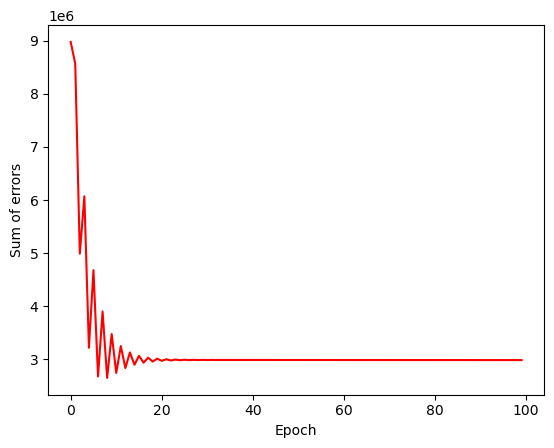

In [338]:
alpha = 0.0005
charges_pred_FBGD_1 = check_gradient_descent_for(alpha)

For alpha = 0.0001
Coefficients: 220.15455659787733 0.2129582687167225
RMSE: 4715.349747703003


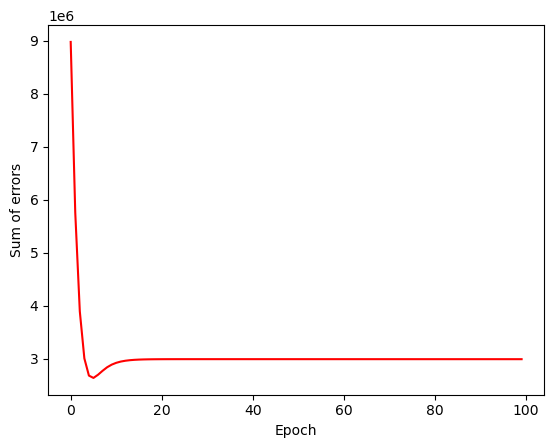

In [339]:
alpha = 0.0001
charges_pred_FBGD_2 = check_gradient_descent_for(alpha)

For alpha = 5e-05
Coefficients: 220.10120618595232 2.5824031319565828
RMSE: 4715.46886823035


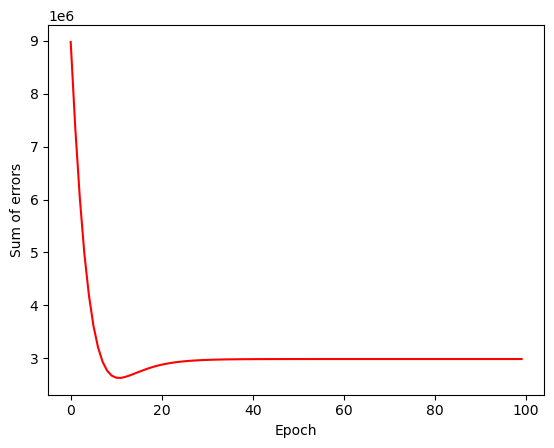

In [340]:
alpha = 0.00005
charges_pred_FBGD_3 = check_gradient_descent_for(alpha)

**Висновок**
Найкраще значення з перевірених alpha = 0.0005, тому що воно дає найменший RMSE.

#### 3. За допомогою бібліотеки `scikit-learn.LinearRegression`

In [341]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

In [342]:
lin_reg.fit(ages.to_frame(), charges)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [343]:
m, b = lin_reg.coef_[0], lin_reg.intercept_
m, b

(np.float64(267.2489128311981), np.float64(-2091.4205565650245))

In [358]:
# Predicted target values
charges_pred_sklearn = lin_reg.predict(ages.to_frame())

# Calculcate RMSE
rmse = calculate_rmse(charges_pred_sklearn)
rmse

np.float64(4662.505766636395)

#### Порівняльний графік

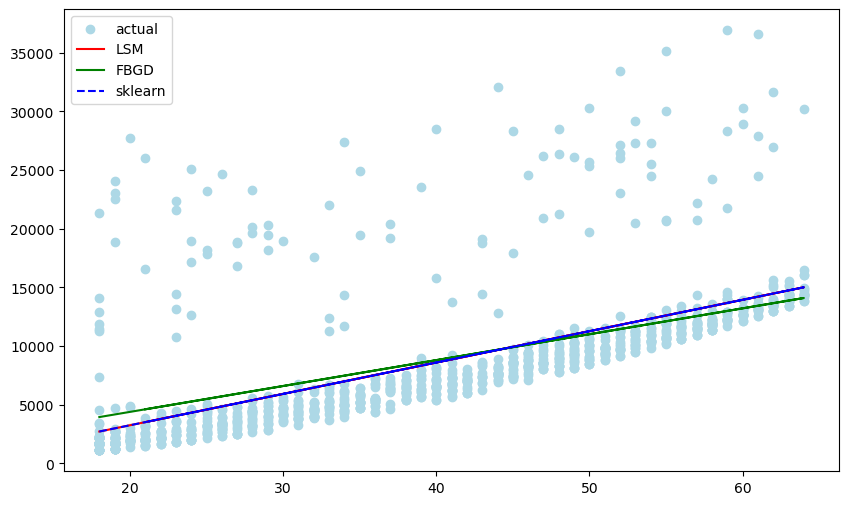

In [345]:
plt.figure(figsize=(10, 6))
plt.scatter(x=ages, y=charges, color="lightblue", label='actual')
plt.plot(ages, charges_pred_LSM, color="red", label="LSM")
plt.plot(ages, charges_pred_FBGD_1, color="green", label="FBGD")
plt.plot(ages, charges_pred_sklearn, color="blue", linestyle="--", label="sklearn")
plt.legend()
plt.show()

**Висновок**
- Результат для Методу Найменших Квадратів і бібліотеки `sklearn` співпадають. Бо під капотом у бібліотеки використовується той самий МНК. Метод Градієнтного спуску дав трохи гірший результат.
- Мої найкращі припущення з попереднього ДЗ показали дещо гірший результат, ніж ці методи, хоч і не значно.
- При цьому коефіцієнти відрізняються доволі сильно, особливо у порівнянні з результатами методу Градієнтного спуску.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [346]:
smoker_df = medical_df[medical_df['smoker'] == 'yes']
smoker_df.shape
smoker_ages = smoker_df.age
smoker_charges = smoker_df.charges

In [353]:
# Train model
lin_reg_smoker = LinearRegression()
lin_reg_smoker.fit(smoker_ages.to_frame(), smoker_charges)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [354]:
# Calculate coefficients
m, b = lin_reg_smoker.coef_[0], lin_reg_smoker.intercept_
m, b

(np.float64(305.23760210982874), np.float64(20294.12812691597))

In [349]:
# Predicted target values
charges_pred_smoker = lin_reg_smoker.predict(smoker_ages.to_frame())

In [355]:
# Check accuracy metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

r2 = r2_score(smoker_charges, charges_pred_smoker)
rmse = root_mean_squared_error(smoker_charges, charges_pred_smoker)
mae = mean_absolute_error(smoker_charges, charges_pred_smoker)

print(f"R² score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² score: 0.14
Root Mean Squared Error: 10711.00
Mean Absolute Error: 10097.80


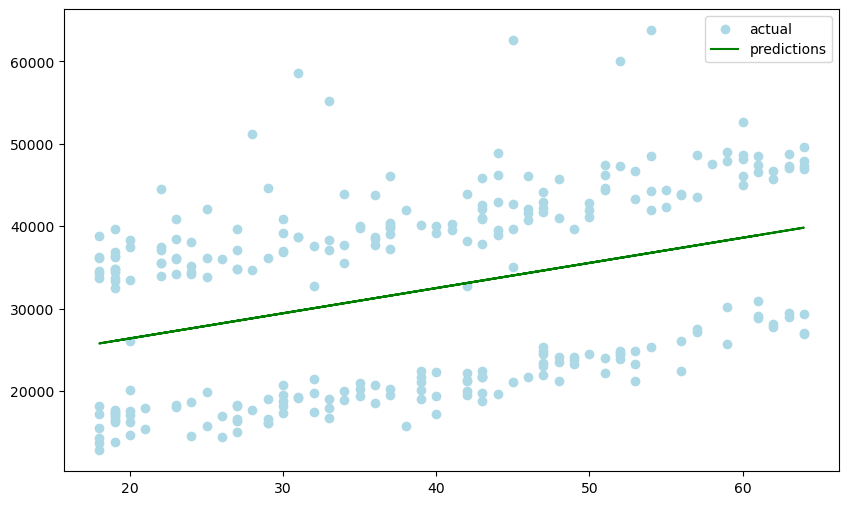

In [356]:
# Build scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(x=smoker_ages, y=smoker_charges, color="lightblue", label='actual')
plt.plot(smoker_ages, charges_pred_smoker, color="green", label="predictions")
plt.legend()
plt.show()

**Спостереження**
- Для даних курців RMSE має значення суттєво більше, ніж для некурців.
- На графіку видно, що лінія передбачень знаходиться у майже пустій ділянці між двома скупченями актуальних даних.
- Оцінка R² = 0.14, що свідчить про близькість розміру помилок до варіативності реальних значень.

**Висновок**
- Ця модель не підходить для підрахунку медичних зборів для курців.